## Brett T. Burtner
### DDS-8555 Predictive Analysis
### Dr. Sebhat Gezehey
### ISLP Problem 3.10

In [27]:
# Import packages expected to be used
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error as myMSE
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import os

In [2]:
# Read 'Carseats.csv'  ad dataframe
df = pd.read_csv('Carseats.csv')
df.head(12) # Displays df

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
5,10.81,124,113,13,501,72,Bad,78,16,No,Yes
6,6.63,115,105,0,45,108,Medium,71,15,Yes,No
7,11.85,136,81,15,425,120,Good,67,10,Yes,Yes
8,6.54,132,110,0,108,124,Medium,76,10,No,No
9,4.69,132,113,0,131,124,Medium,76,17,No,Yes


In [3]:
df.info() # Output shows no NAs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [4]:
df.describe() # Shows stats for numerical variables

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


### Show unique values for categorical variables

In [5]:
print("Unique ShelveLoc unique values: ",df['ShelveLoc'].unique())
print("Unique Urban unique values: ",df['Urban'].unique())
print("Unique US unique values: ",df['US'].unique())

Unique ShelveLoc unique values:  ['Bad' 'Good' 'Medium']
Unique Urban unique values:  ['Yes' 'No']
Unique US unique values:  ['Yes' 'No']


### Enumerates categorical variable values

In [6]:
mapping = {'Good': 2, 'Medium': 1, 'Bad': 0}
df['ShelveLoc'] = df['ShelveLoc'].replace(mapping)
mapping = {'Yes': 1, 'No': 0}
df['Urban'] = df['Urban'].replace(mapping)
mapping = {'Yes': 1, 'No': 0}
df['US'] = df['US'].replace(mapping)
df.head(12)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,2,65,10,1,1
2,10.06,113,35,10,269,80,1,59,12,1,1
3,7.40,117,100,4,466,97,1,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0
5,10.81,124,113,13,501,72,0,78,16,0,1
6,6.63,115,105,0,45,108,1,71,15,1,0
7,11.85,136,81,15,425,120,2,67,10,1,1
8,6.54,132,110,0,108,124,1,76,10,0,0
9,4.69,132,113,0,131,124,1,76,17,0,1


### Exploratory Data Analysis

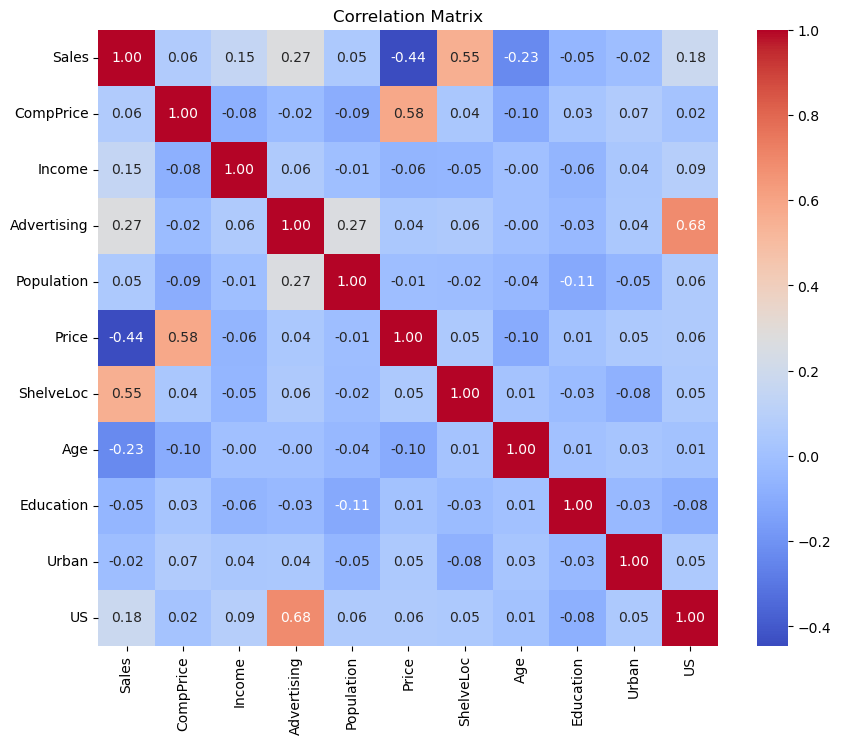

In [7]:
# Correlation matrix
correlation_matrix = df.corr() # Compute correlations
plt.figure(figsize=(10, 8)) # Adjust figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

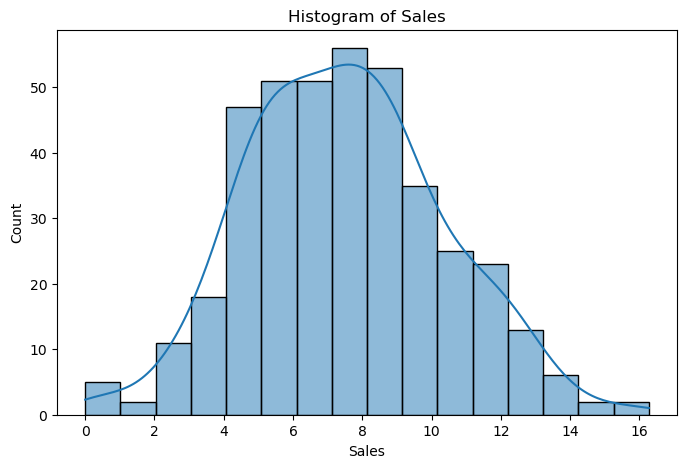

In [8]:
# Histogram of Sales
plt.figure(figsize = (8,5))
sns.histplot(df['Sales'], kde = True)
plt.title("Histogram of Sales")
plt.show()

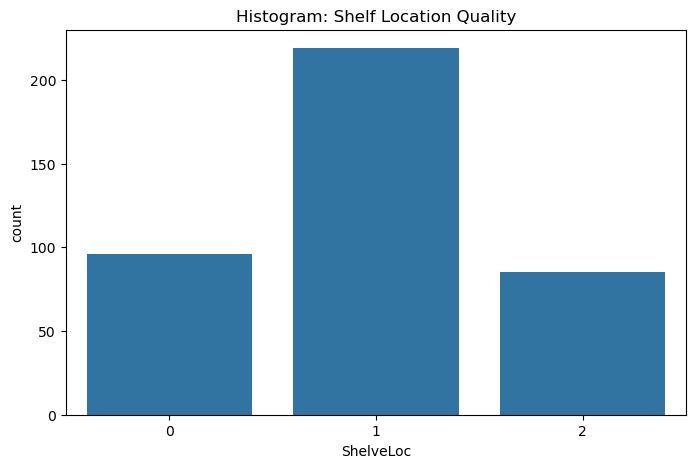

In [9]:
# Histogram of ShelveLoc variable
plt.figure(figsize=(8, 5))
sns.countplot(x='ShelveLoc', data = df)
plt.title('Histogram: Shelf Location Quality')
plt.show()

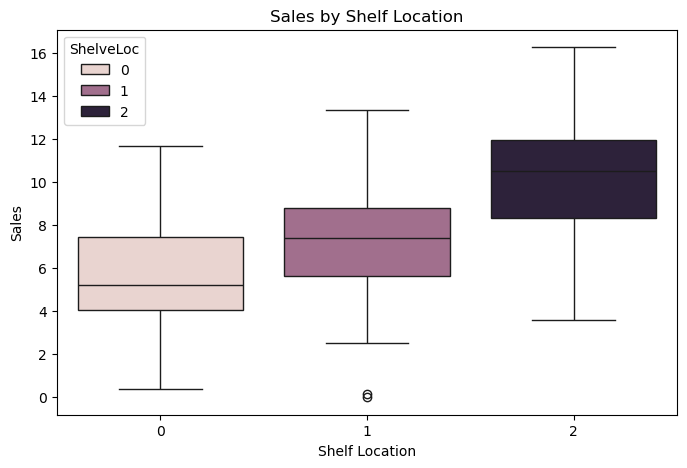

In [10]:
# Boxplots of Price versus Sales
plt.figure(figsize = (8,5))
sns.boxplot(x = 'ShelveLoc', y = 'Sales', data = df, hue = 'ShelveLoc')
plt.title('Sales by Shelf Location')
plt.xlabel("Shelf Location")
plt.show()

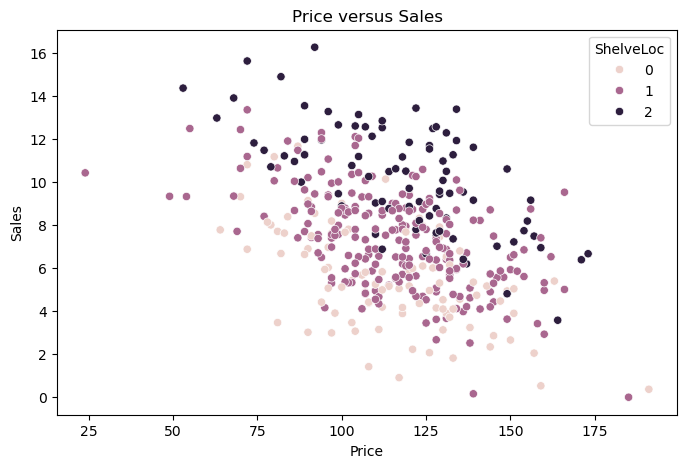

In [11]:
# Scatterplot of Price versus Sales
plt.figure(figsize = (8, 5))
sns.scatterplot(x = 'Price', y = 'Sales', hue = 'ShelveLoc', data = df)
plt.title("Price versus Sales")
plt.show()

## Split data

In [12]:
# Define X and y portions of the dataset
X = df.drop(columns = ['Sales'])
y = df['Sales']

# Split the dataset 80/20
X_train, X_test, y_train, y_test = tts(X,
                                       y,
                                       train_size = 0.8,
                                       test_size = 0.2,
                                       shuffle = True,
                                       random_state = 42)

### Chapter 3 questions

10.a
First regression model

In [13]:
model1 = smf.ols(formula = 'Sales ~ Price + Urban + US', data = df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           2.39e-23
Time:                        13:28:11   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0435      0.651     20.036      0.0


10.b

In the first model, the intercept is at a y-value of 13.0435.
Price (enumerated) is only very slightly negatively correlated at -0.0545.
Urban (enumerated) also is only slightly negatively correlated at -0.0219.
US is very slightly positively correlated at 1.206.

10.c

y = 13.0435 + (Price * -0.0545) + (Urban * -0.0219) + (US * 1.2006)

10.d

For Price and US, I can reject the value, since their p-values are significantly less than 0.05.  For Urban, the null hypothesis cannot be rejected, since it's p-velue is far greater than 0.05 (0.936).

10.e
Second regression model

In [14]:
# Leaving Urban out of this second model
model2 = smf.ols(formula = 'Sales ~ Price  + US', data = df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           2.66e-24
Time:                        13:28:11   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631     20.652      0.0

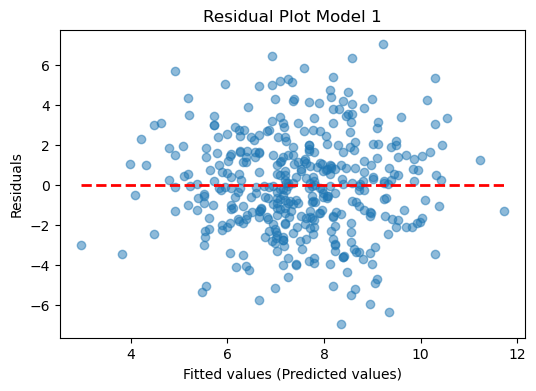

In [15]:
# Produce residuals plot for Model 1
y_pred = model1.predict(X)
residuals = y - y_pred
plt.figure(figsize = (6, 4))
plt.scatter(y_pred, residuals, alpha = 0.5)
plt.hlines(y = 0,
            xmin = min(y_pred),
            xmax = max(y_pred),
            color = 'red',
            linestyle = '--',
            lw = 2)
plt.xlabel('Fitted values (Predicted values)')
plt.ylabel('Residuals')
plt.title('Residual Plot Model 1')  
plt.show()


10.f

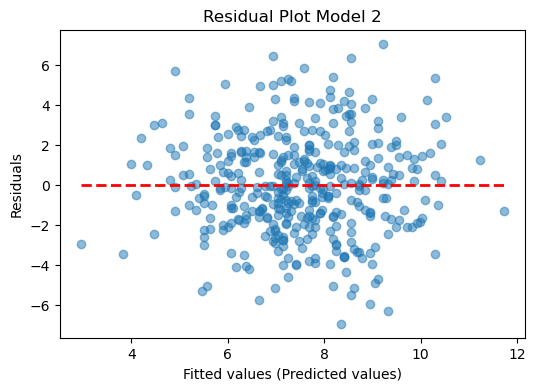

In [16]:
# Produce residuals plot for Model 2
y_pred = model2.predict(X)
residuals = y - y_pred
plt.figure(figsize = (6, 4))
plt.scatter(y_pred, residuals, alpha = 0.5)
plt.hlines(y = 0,
            xmin = min(y_pred),
            xmax = max(y_pred),
            color = 'red',
            linestyle = '--',
            lw = 2)
plt.xlabel('Fitted values (Predicted values)')
plt.ylabel('Residuals')
plt.title('Residual Plot Model 2')  
plt.show()

In [17]:
# F test for model1
f_test_results = anova_lm(model1, typ = 2)
print(f_test_results)

               sum_sq     df           F        PR(>F)
Price      659.837263    1.0  107.936143  1.609917e-22
Urban        0.039790    1.0    0.006509  9.357389e-01
US         131.313130    1.0   21.480194  4.860245e-06
Residual  2420.834671  396.0         NaN           NaN


In [18]:
# F test for model2
f_test_results = anova_lm(model2, typ = 2)
print(f_test_results)

               sum_sq     df           F        PR(>F)
Price      661.597655    1.0  108.495617  1.272157e-22
US         131.369831    1.0   21.543382  4.707187e-06
Residual  2420.874462  397.0         NaN           NaN


In [25]:
# MSE comparison
y_pred1 = model1.predict(X_test)
mse1 = myMSE(y_test, y_pred1)
print('MSE for Model 1: ', mse1)

MSE for Model 1:  7.670674709078952


In [26]:
y_pred2 = model2.predict(X_test)
mse2 = myMSE(y_test, y_pred2)
print('MSE for Model 2: ', mse2)

MSE for Model 2:  7.6676375026523775


Both models seem to fit the data rather well since the p-values are very small.  If I had to pick one of the models, I would pick model 2, since the MSE is ever so slightly smaller.  That said, both models would likely perform similarly with respect to quality.

10.g

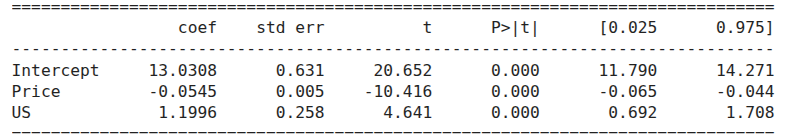

See right-hand side of snapshot for 97.5% confidence interval for each coefficient.

10.h

Upon visual inspection of the residuals plot for model 2, it appears there are no radical outliers.